# Machine Learning I Group Assignment — Section 1 Group 5
## Madrid Rental Market: Segmentation + Linear Regression Pipeline

---
## **1. Data Audit, Data Cleaning and Data Manipulation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    r2_score, mean_absolute_error, mean_squared_error
)
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedKFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_columns', None)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### **1.1. Data Exploration and Data Cleaning**

In [2]:
# Load data
path = "Houses for rent in Madrid.xlsx"
df = pd.read_excel(path)

print("Shape:", df.shape)
display(df.head())

Shape: (2089, 15)


,Id,District,Address,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,1,Ciudad Lineal,Piso en Quintana,NaN,Quintana,1300,2.00,72,3.00,1.00,1.00,0,0,0,0
1,2,Ciudad Lineal,Piso en calle de Arturo Soria,NaN,Costillares,3000,5.00,260,2.00,1.00,1.00,0,0,0,0
2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,4,Colina,1300,2.00,100,3.00,1.00,1.00,0,0,0,0
3,4,Ciudad Lineal,Piso en calle Badajoz,NaN,San Pascual,1600,3.00,120,4.00,1.00,1.00,0,0,0,0
4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,9,Ventas,800,2.00,60,3.00,1.00,0.00,0,0,0,0


In [3]:
# Data audit: data types, missing values, cardinality
audit = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_n": df.isnull().sum(),
    "missing_%": (df.isnull().sum() / len(df) * 100).round(2),
    "n_unique": df.nunique()
}).sort_values("missing_%", ascending=False)

display(audit)

,dtype,missing_n,missing_%,n_unique
Number,str,1342,64.24,137
Outer,float64,162,7.75,2
Floor,float64,141,6.75,29
Elevator,float64,133,6.37,2
Bedrooms,float64,89,4.26,9
Area,str,4,0.19,140
Id,int64,0,0.00,2089
District,str,0,0.00,20
Address,str,0,0.00,1336
Rent,int64,0,0.00,250


In [4]:
# Create a new dataframe to store cleaned data
df_clean = df.copy()

In [5]:
# Categorical variables
cat_cols = df_clean.select_dtypes(include=["object", "string", "category"]).columns
print(cat_cols)

cat_summary = df_clean[cat_cols].describe().T[["count", "unique", "top", "freq"]]
cat_summary

Index(['District', 'Address', 'Number', 'Area'], dtype='str')


,count,unique,top,freq
District,2089,20,Salamanca,313
Address,2089,1336,Piso en Castellana,25
Number,747,137,1,29
Area,2085,140,Recoletos,93


In [6]:
# Extract unique values for Categorical variables
for col in cat_cols:
    uniques = df_clean[col].dropna().unique()
    print(f"\n {col} ({len(uniques)} unique values)")
    print(sorted(uniques))


 District (20 unique values)
['Arganzuela', 'Barajas', 'Carabanchel', 'Centro', 'Chamartín', 'Chamberí', 'Ciudad Lineal', 'Fuencarral', 'Hortaleza', 'Latina', 'Moncloa', 'Moratalaz', 'Puente Vallecas', 'Retiro', 'Salamanca', 'San Blás', 'Tetuán', 'Usera', 'Vicálvaro', 'Villa de Vallecas']

 Address (1336 unique values)
['Casa o chalet independiente en Algabeño', 'Casa o chalet independiente en Aravaca', 'Casa o chalet independiente en Canillas', 'Casa o chalet independiente en Ciudad Universitaria', 'Casa o chalet independiente en Conde Orgaz-Piovera', 'Casa o chalet independiente en El Plantío', 'Casa o chalet independiente en Fuentelarreina', 'Casa o chalet independiente en Niño Jesús', 'Casa o chalet independiente en Nueva España', 'Casa o chalet independiente en Urbanización La Florida', 'Casa o chalet independiente en Valdebebas - Valdefuentes', 'Casa o chalet independiente en Valdemarín', 'Casa o chalet independiente en calle Aldea Real', 'Casa o chalet independiente en calle Ca

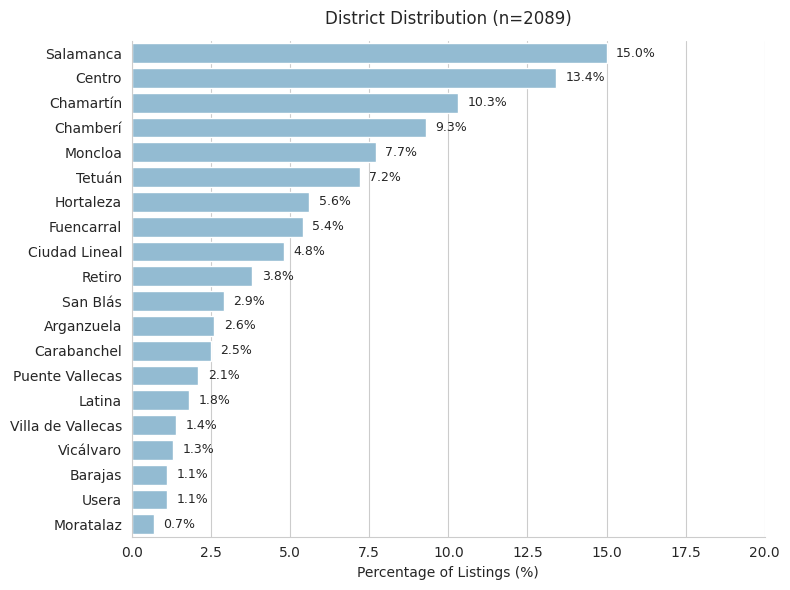

In [7]:
# District composition
col = "District"

vc = df[col].value_counts(dropna=False)
pct = (vc / vc.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    x=pct.values,
    y=pct.index,
    color=sns.color_palette("Blues_r")[3],
    ax=ax
)

for i, (val, name) in enumerate(zip(pct.values, pct.index)):
    ax.text(val + 0.3, i, f"{val}%", va="center", fontsize=9)

ax.set_title(f"{col} Distribution (n={len(df)})", fontsize=12, pad=12)
ax.set_xlabel("Percentage of Listings (%)")
ax.set_ylabel("")
ax.set_xlim(0, pct.values.max() + 5)

sns.despine()
plt.tight_layout()
plt.show()

In [8]:
# Numerical variables
df_clean.describe()

,Id,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
count,2089.00,2089.00,2000.00,2089.00,1948.00,1927.00,1956.00,2089.00,2089.00,2089.00,2089.00
mean,1094.03,1932.25,2.48,128.92,25.66,0.87,0.88,0.08,0.04,0.03,0.01
std,630.61,1495.47,1.31,115.75,975.07,0.34,0.32,0.27,0.20,0.17,0.12
min,1.00,450.00,0.00,15.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,550.00,950.00,2.00,65.00,2.00,1.00,1.00,0.00,0.00,0.00,0.00
50%,1094.00,1400.00,2.00,90.00,3.00,1.00,1.00,0.00,0.00,0.00,0.00
75%,1636.00,2500.00,3.00,147.00,5.00,1.00,1.00,0.00,0.00,0.00,0.00
max,2188.00,16000.00,8.00,1250.00,43039.00,1.00,1.00,1.00,1.00,1.00,1.00


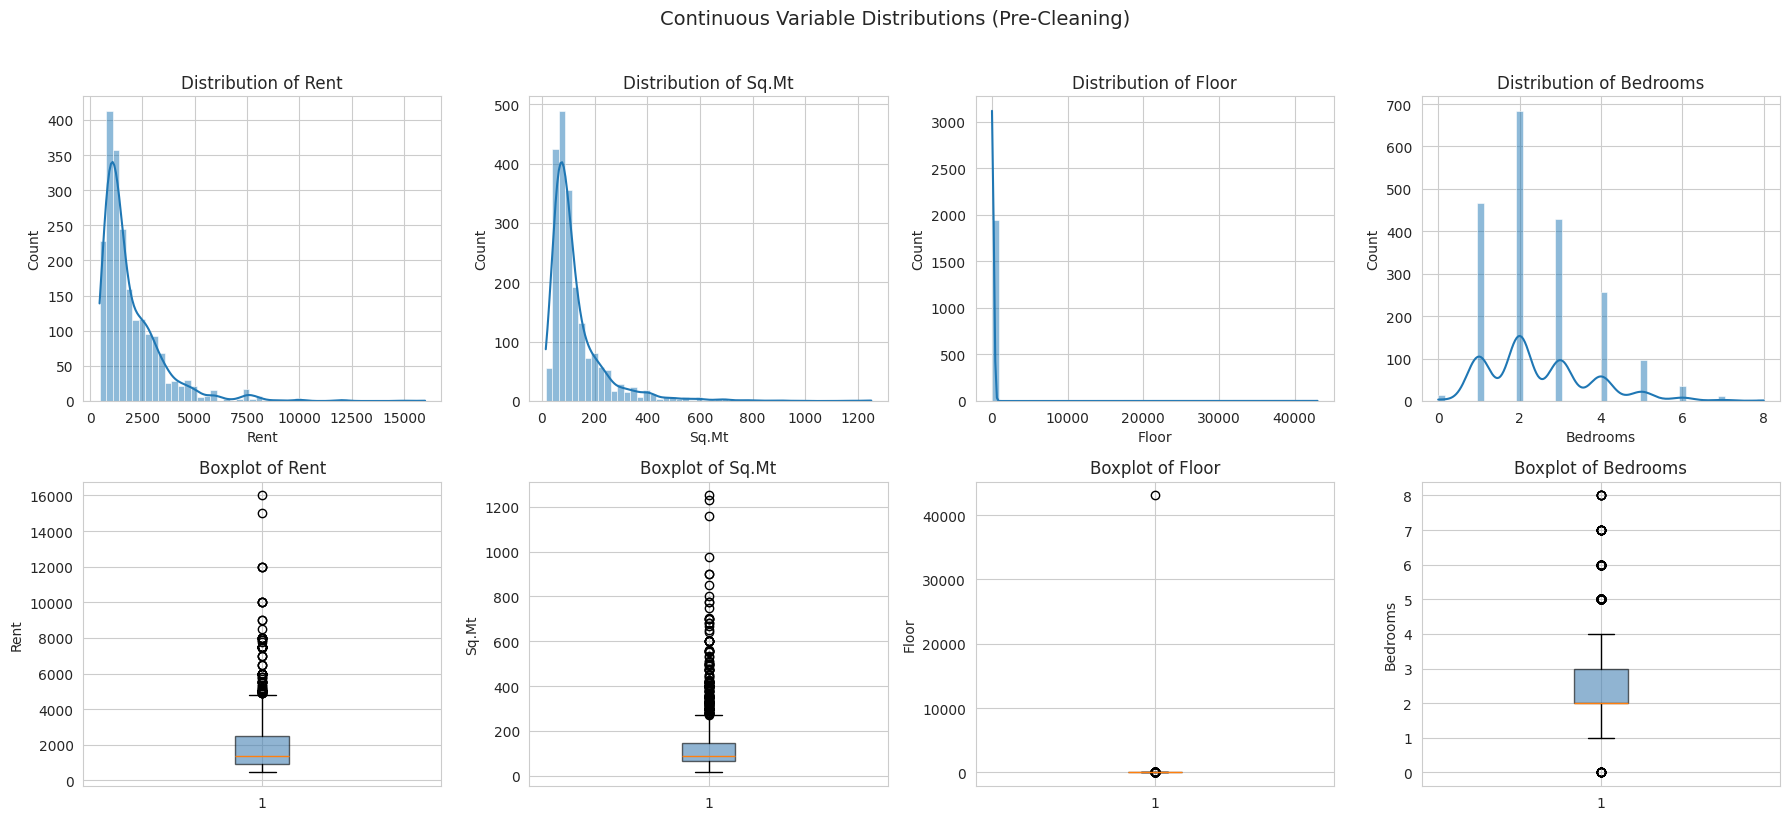

In [9]:
# Distribution of continuous variables to identify outliers visually
continuous_cols = ['Rent', 'Sq.Mt', 'Floor', 'Bedrooms']

fig, axes = plt.subplots(2, len(continuous_cols), figsize=(18, 8))

for i, col in enumerate(continuous_cols):
    # Histogram (top row)
    sns.histplot(df_clean[col].dropna(), bins=50, kde=True, ax=axes[0, i])
    axes[0, i].set_title(f"Distribution of {col}")
    
    # Boxplot (bottom row)
    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, i].set_title(f"Boxplot of {col}")
    axes[1, i].set_ylabel(col)

plt.suptitle("Continuous Variable Distributions (Pre-Cleaning)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Remove structural outliers identified from distribution plots
before_rows = df_clean.shape[0]
print(f"Shape before outlier removal: {df_clean.shape}")

df_clean = df_clean[(df_clean["Floor"] <= 50) & (df_clean["Sq.Mt"] <= 500)]

after_rows = df_clean.shape[0]
removed = before_rows - after_rows
removed_pct = removed / before_rows * 100

print(f"Shape after outlier removal: {df_clean.shape}")
print(f"Observations removed: {removed} ({removed_pct:.2f}%)")

Shape before outlier removal: (2089, 15)
Shape after outlier removal: (1940, 15)
Observations removed: 149 (7.13%)


In [11]:
# Check for statistical summary after removal
df_clean.describe()

,Id,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
count,1940.00,1940.00,1853.00,1940.00,1940.00,1905.00,1920.00,1940.00,1940.00,1940.00,1940.00
mean,1120.20,1811.33,2.36,113.47,3.58,0.87,0.89,0.09,0.00,0.03,0.00
std,622.64,1269.85,1.17,74.95,3.01,0.33,0.31,0.28,0.04,0.18,0.03
min,1.00,450.00,0.00,15.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,614.75,950.00,1.00,65.00,2.00,1.00,1.00,0.00,0.00,0.00,0.00
50%,1124.50,1400.00,2.00,90.00,3.00,1.00,1.00,0.00,0.00,0.00,0.00
75%,1657.25,2300.00,3.00,135.00,5.00,1.00,1.00,0.00,0.00,0.00,0.00
max,2188.00,16000.00,8.00,500.00,29.00,1.00,1.00,1.00,1.00,1.00,1.00


### **1.2. Feature Engineering & Further Data Cleaning**

In [12]:
# Create Studio column from Address text (structural missingness resolution)
df_clean["Studio"] = df_clean["Address"].str.lower().str.contains("estudio", na=False).astype(int)
df_clean.loc[df_clean["Studio"] == 1, "Bedrooms"] = 0
print(f"Studios detected: {df_clean['Studio'].sum()}")

Studios detected: 88


In [13]:
# Drop irrelevant columns
df_clean = df_clean.drop(columns=["Id", "Address","Number"])

In [14]:
before = len(df_clean)

df_clean = df_clean.dropna(subset=["Outer", "Floor", "Elevator", "Bedrooms"])

after = len(df_clean)

rows_removed = before - after
percent_removed = (rows_removed / before) * 100

print(f"Rows before: {before}")
print(f"Rows after: {after}")
print(f"Rows removed: {rows_removed}")
print(f"Percentage removed: {percent_removed:.2f}%")

Rows before: 1940
Rows after: 1893
Rows removed: 47
Percentage removed: 2.42%


In [15]:
# Check missing rows after dropping
df_clean.isna().sum()

District        0
Area            4
Rent            0
Bedrooms        0
Sq.Mt           0
Floor           0
Outer           0
Elevator        0
Penthouse       0
Cottage         0
Duplex          0
Semidetached    0
Studio          0
dtype: int64

In [16]:
# Check data after cleaning
df_clean.describe()

,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,Studio
count,1893.00,1893.00,1893.00,1893.00,1893.00,1893.00,1893.00,1893.00,1893.00,1893.00,1893.00
mean,1820.10,2.26,114.18,3.59,0.87,0.89,0.08,0.00,0.03,0.00,0.05
std,1277.60,1.24,75.22,3.00,0.33,0.31,0.28,0.04,0.18,0.03,0.21
min,450.00,0.00,20.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,950.00,1.00,65.00,2.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
50%,1400.00,2.00,90.00,3.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
75%,2300.00,3.00,136.00,5.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
max,16000.00,8.00,500.00,29.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


---
## **2. Segmentation**

K-means clustering is adopted for segmentation. 

In [17]:
# Separate target variable (excluded from clustering)
target = "Rent"
df_seg = df_clean.copy()
df_seg = df_seg.drop(columns=target)

print(df_seg.shape)
df_seg.head()

(1893, 12)


,District,Area,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,Studio
0,Ciudad Lineal,Quintana,2.00,72,3.00,1.00,1.00,0,0,0,0,0
1,Ciudad Lineal,Costillares,5.00,260,2.00,1.00,1.00,0,0,0,0,0
2,Ciudad Lineal,Colina,2.00,100,3.00,1.00,1.00,0,0,0,0,0
3,Ciudad Lineal,San Pascual,3.00,120,4.00,1.00,1.00,0,0,0,0,0
4,Ciudad Lineal,Ventas,2.00,60,3.00,1.00,0.00,0,0,0,0,0


In [18]:
df_seg.describe()

,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,Studio
count,1893.00,1893.00,1893.00,1893.00,1893.00,1893.00,1893.00,1893.00,1893.00,1893.00
mean,2.26,114.18,3.59,0.87,0.89,0.08,0.00,0.03,0.00,0.05
std,1.24,75.22,3.00,0.33,0.31,0.28,0.04,0.18,0.03,0.21
min,0.00,20.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,65.00,2.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
50%,2.00,90.00,3.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
75%,3.00,136.00,5.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
max,8.00,500.00,29.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


### **2.1. Features Selection and Exploratory Data Analysis (Pre-Segmentation)**

In [19]:
# Clustering features: structural characteristics only
# Excluded: Rent (circular), District/Area (geographic), Floor/Elevator/Outer (amenities)
features = ['Sq.Mt', 'Bedrooms', 'Penthouse', 'Cottage', 'Duplex', 'Semidetached', 'Studio']
x = df_seg[features]

In [20]:
# Separate numeric vs binary for appropriate plots
numeric_feats = [c for c in x.columns if x[c].nunique() > 5]
binary_feats  = [c for c in x.columns if x[c].nunique() <= 5]

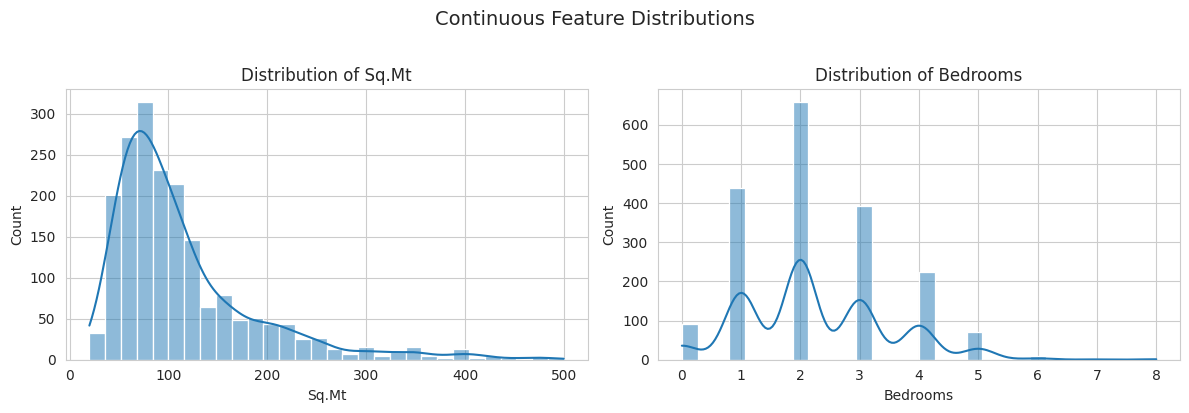

In [21]:
# Distributions of continuous numeric features
fig, axes = plt.subplots(1, len(numeric_feats), figsize=(12, 4))
if len(numeric_feats) == 1: axes = [axes]
for i, col in enumerate(numeric_feats):
    sns.histplot(x[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.suptitle("Continuous Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

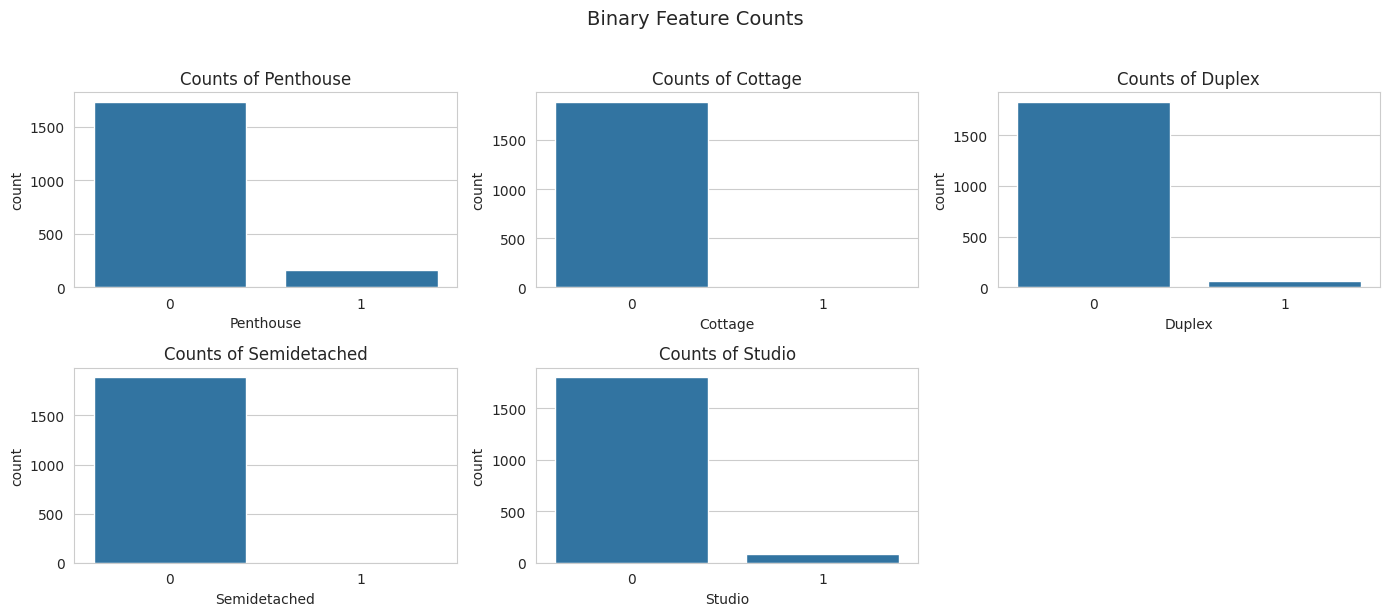

In [22]:
# Binary feature counts
n_cols = 3
n_rows = (len(binary_feats) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes = axes.flatten()
for i, col in enumerate(binary_feats):
    sns.countplot(x=x[col], ax=axes[i])
    axes[i].set_title(f"Counts of {col}")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Binary Feature Counts", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### **2.2 Correlation & Redundancy Analysis**

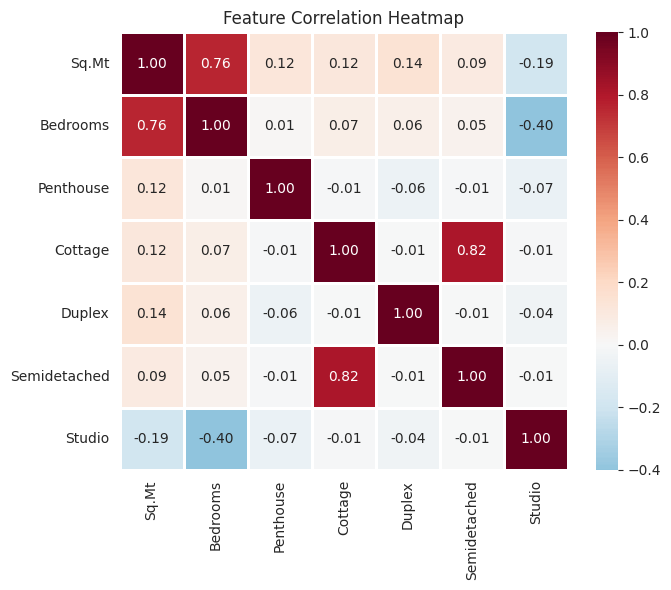

In [23]:
# Correlation heatmap (full matrix)
corr_matrix = x.corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=1, ax=ax, cmap="RdBu_r", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [24]:
# Flag potentially redundant pairs (|corr| > 0.6)
corr_pairs = corr_matrix.abs().unstack().reset_index()
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs = corr_pairs[corr_pairs["feature_1"] < corr_pairs["feature_2"]]  # unique pairs only
corr_pairs = corr_pairs[corr_pairs["correlation"] > 0.6].sort_values("correlation", ascending=False)

print("Strong correlation pairs (potential redundancy):")
display(corr_pairs if len(corr_pairs) > 0 else "No pairs above 0.6 threshold.")

Strong correlation pairs (potential redundancy):


,feature_1,feature_2,correlation
26,Cottage,Semidetached,0.82
7,Bedrooms,Sq.Mt,0.76


### **2.3 Rescaling**

In [25]:
# Z-score standardisation (required for distance-based clustering)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print(f"Original Sq.Mt — mean: {x['Sq.Mt'].mean():.1f}, std: {x['Sq.Mt'].std():.1f}")
print("After scaling: mean ≈ 0.0, std ≈ 1.0 (by definition)")

Original Sq.Mt — mean: 114.2, std: 75.2
After scaling: mean ≈ 0.0, std ≈ 1.0 (by definition)


### **2.4 Determining Optimal Number of Clusters**

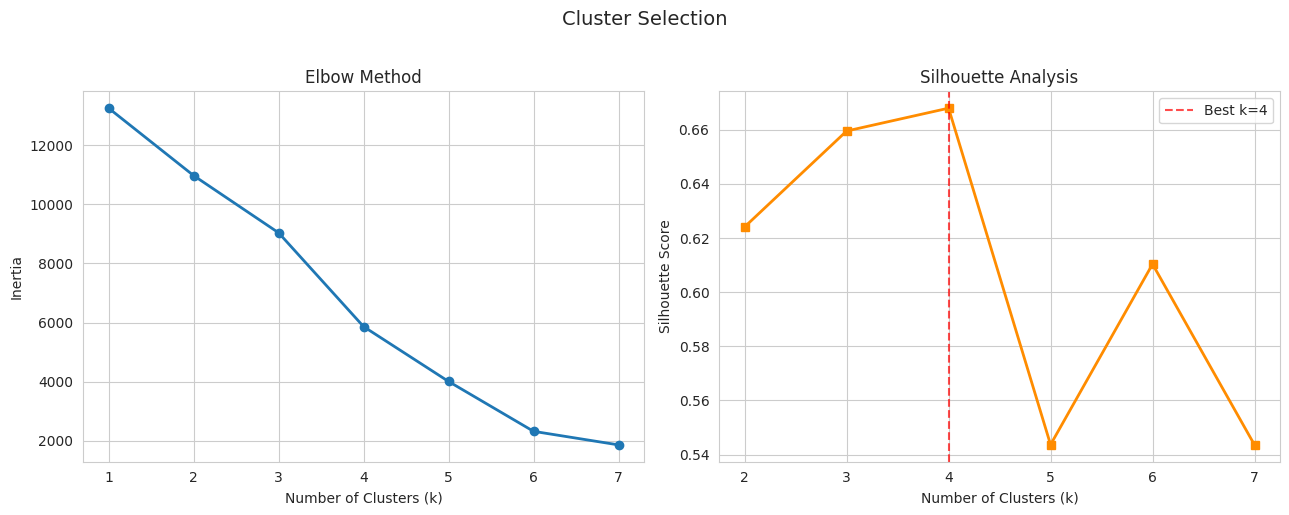


Silhouette scores:
  k=2: 0.624
  k=3: 0.660
  k=4: 0.668 ← best
  k=5: 0.544
  k=6: 0.610
  k=7: 0.544


In [26]:
# Elbow Method + Silhouette Score (side-by-side)
K_range_elbow = range(1, 8)  # starts from 1 for elbow
K_range_sil = range(2, 8)    # starts from 2 for silhouette

# Elbow: compute inertia from k=1
inertia_vals = []
for k in K_range_elbow:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(x_scaled)
    inertia_vals.append(km.inertia_)

# Silhouette: compute from k=2
silhouette_vals = []
for k in K_range_sil:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(x_scaled)
    silhouette_vals.append(silhouette_score(x_scaled, labels))

best_k = list(K_range_sil)[np.argmax(silhouette_vals)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Elbow chart (k=1 to 7)
ax1.plot(list(K_range_elbow), inertia_vals, marker='o', linewidth=2)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")
ax1.set_xticks(list(K_range_elbow))

# Silhouette chart (k=2 to 7)
ax2.plot(list(K_range_sil), silhouette_vals, marker='s', linewidth=2, color='darkorange')
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Analysis")
ax2.set_xticks(list(K_range_sil))
ax2.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
ax2.legend()

plt.suptitle("Cluster Selection", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K_range_sil, silhouette_vals):
    marker = " ← best" if k == best_k else ""
    print(f"  k={k}: {s:.3f}{marker}")

In [27]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_seg['Cluster'] = kmeans.fit_predict(x_scaled)

In [28]:
# Shift to 1-indexed for readability
df_seg['Cluster'] = df_seg['Cluster'] + 1

print("Cluster sizes:")
print(df_seg['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
1      88
2    1741
3      62
4       2
Name: count, dtype: int64


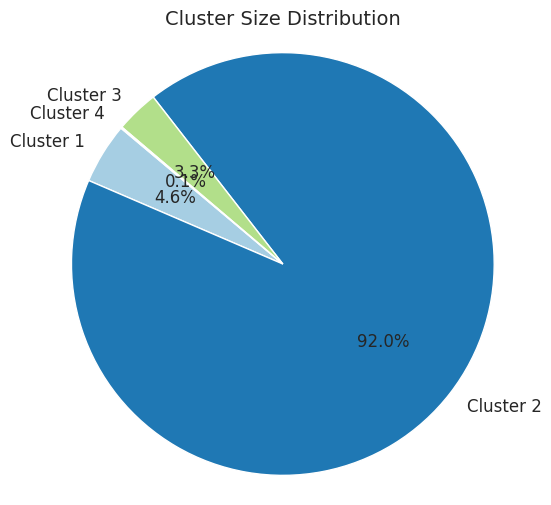

In [29]:
# Pie chart of cluster distribution
cluster_sizes = df_seg['Cluster'].value_counts().sort_index()
plt.figure(figsize=(6, 6))
plt.pie(
    cluster_sizes.values,
    labels=[f"Cluster {c}" for c in cluster_sizes.index],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors,
    textprops={'fontsize': 12}
)
plt.title('Cluster Size Distribution', fontsize=14)
plt.axis('equal')
plt.show()

### **2.5. Global & Individual Silhouette Analysis**

In [30]:
# Global silhouette
silhouette_avg = silhouette_score(x_scaled, df_seg['Cluster'])
print(f"Global Silhouette Score: {silhouette_avg:.3f}")

Global Silhouette Score: 0.668


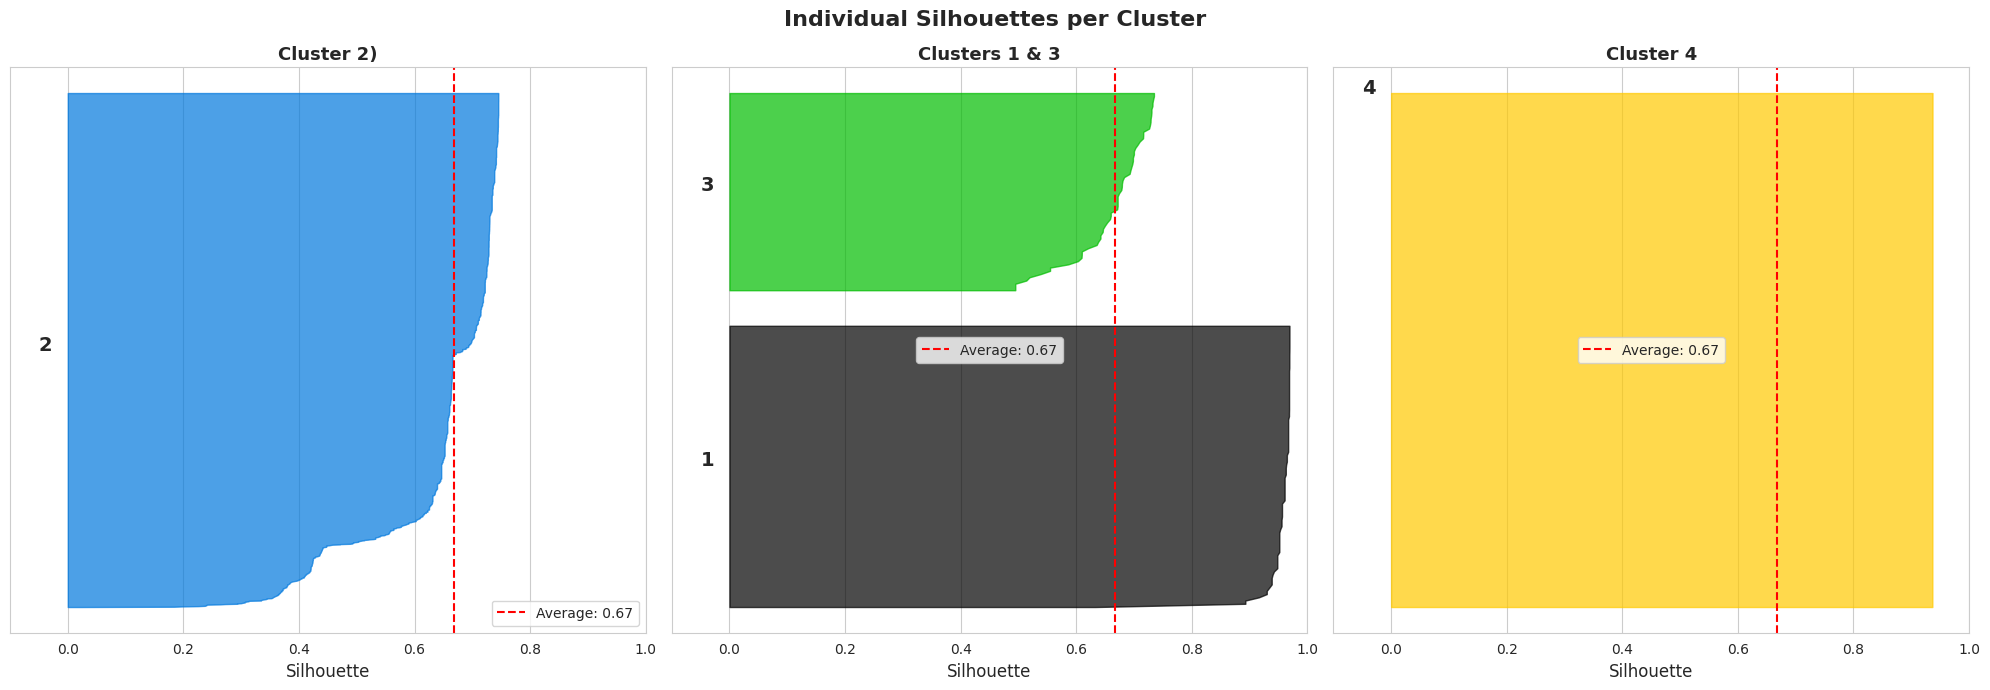

In [31]:
# Individual silhouette plot (per-cluster quality)
sample_silhouette_values = silhouette_samples(x_scaled, df_seg['Cluster'])
labels = np.array(df_seg['Cluster'])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

# Plot Cluster 2 (on the left)
y_lower = 10
ith_values = sample_silhouette_values[labels == 2]
ith_values.sort()
color = cm.nipy_spectral(1 / 4)
ax1.fill_betweenx(np.arange(y_lower, y_lower + len(ith_values)), 0, ith_values,
                  facecolor=color, edgecolor=color, alpha=0.7)
ax1.text(-0.05, y_lower + 0.5 * len(ith_values), '2', fontsize=14, fontweight='bold')
ax1.set_title("Cluster 2)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Silhouette", fontsize=12)
ax1.axvline(x=silhouette_avg, color="red", linestyle="--",
            label=f'Average: {silhouette_avg:.2f}')
ax1.set_xlim([-0.1, 1.0])
ax1.set_yticks([])
ax1.legend()

# Plot Clusters 1 & 3 (in the middle)
y_lower = 10
for cluster_id in [1, 3]:
    ith_values = sample_silhouette_values[labels == cluster_id]
    ith_values.sort()
    color = cm.nipy_spectral(float(cluster_id - 1) / 4)
    y_upper = y_lower + len(ith_values)
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax2.text(-0.05, y_lower + 0.5 * len(ith_values), str(cluster_id),
             fontsize=14, fontweight='bold')
    y_lower = y_upper + 10
ax2.set_title("Clusters 1 & 3", fontsize=13, fontweight='bold')
ax2.set_xlabel("Silhouette", fontsize=12)
ax2.axvline(x=silhouette_avg, color="red", linestyle="--",
            label=f'Average: {silhouette_avg:.2f}')
ax2.set_xlim([-0.1, 1.0])
ax2.set_yticks([])
ax2.legend()

# Plot Cluster 4 (on the right)
y_lower = 10
ith_values = sample_silhouette_values[labels == 4]
ith_values.sort()
color = cm.nipy_spectral(3 / 4)
ax3.fill_betweenx(np.arange(y_lower, y_lower + len(ith_values)), 0, ith_values,
                  facecolor=color, edgecolor=color, alpha=0.7)
ax3.text(-0.05, y_lower + 0.5 * len(ith_values), '4', fontsize=14, fontweight='bold')
ax3.set_title("Cluster 4", fontsize=13, fontweight='bold')
ax3.set_xlabel("Silhouette", fontsize=12)
ax3.axvline(x=silhouette_avg, color="red", linestyle="--",
            label=f'Average: {silhouette_avg:.2f}')
ax3.set_xlim([-0.1, 1.0])
ax3.set_yticks([])
ax3.legend()

plt.suptitle("Individual Silhouettes per Cluster", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **2.6. Calculate relative importance of each variable**

In [32]:
def calculate_importances(df, variables, cluster_col='Cluster'):
    overall_means = df[variables].mean()
    cluster_means = df.groupby(cluster_col)[variables].mean()
    cluster_sizes = df[cluster_col].value_counts()

    # Numerator: variance between clusters
    ss_between = ((cluster_means - overall_means) ** 2).multiply(cluster_sizes, axis=0).sum()

    # Denominator: total variance
    ss_total = ((df[variables] - overall_means) ** 2).sum()

    importance = (ss_between / ss_total).sort_values(ascending=False)
    return importance.to_frame(name='relative importance')

importance_df = calculate_importances(df_seg, variables=features)
print('Variable Importances:\n')
print(importance_df)

Variable Importances:

              relative importance
Duplex                       1.00
Semidetached                 1.00
Studio                       1.00
Cottage                      0.67
Bedrooms                     0.17
Sq.Mt                        0.06
Penthouse                    0.01


### **2.7. Run ANOVA test**

In [33]:
from scipy.stats import f_oneway

results = []
for column in features:
    groups = [df_seg[df_seg['Cluster'] == c][column].values 
              for c in df_seg['Cluster'].unique()]
    f_stat, p_value = f_oneway(*groups)
    avg = df_seg[column].mean()
    results.append({
        'Variable': column,
        'F-statistic': round(f_stat, 2),
        'p-value': round(p_value, 4),
        'Overall Mean': round(avg, 3)
    })

anova_df = pd.DataFrame(results).sort_values('p-value')
anova_df

,Variable,F-statistic,p-value,Overall Mean
0,Sq.Mt,42.25,0.00,114.18
1,Bedrooms,125.02,0.00,2.26
3,Cottage,1257.42,0.00,0.00
4,Duplex,inf,0.00,0.03
5,Semidetached,inf,0.00,0.00
6,Studio,inf,0.00,0.05
2,Penthouse,5.08,0.00,0.08


### **2.8. Clusters profiles**

In [34]:
df_seg.head()

,District,Area,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,Studio,Cluster
0,Ciudad Lineal,Quintana,2.00,72,3.00,1.00,1.00,0,0,0,0,0,2
1,Ciudad Lineal,Costillares,5.00,260,2.00,1.00,1.00,0,0,0,0,0,2
2,Ciudad Lineal,Colina,2.00,100,3.00,1.00,1.00,0,0,0,0,0,2
3,Ciudad Lineal,San Pascual,3.00,120,4.00,1.00,1.00,0,0,0,0,0,2
4,Ciudad Lineal,Ventas,2.00,60,3.00,1.00,0.00,0,0,0,0,0,2


In [35]:
# df_cluster will store cluster averages to calculate profile and global metrics
print("Cluster means (structural features):")
df_cluster = df_seg.groupby('Cluster')[features].mean().round(2)
df_cluster["Average"] = df_cluster.mean(axis=1)
df_cluster["Std.dev"] = df_cluster.std(axis=1)
df_cluster

Cluster means (structural features):


,Sq.Mt,Bedrooms,Penthouse,Cottage,Duplex,Semidetached,Studio,Average,Std.dev
Cluster,,,,,,,,,
1,49.56,0.00,0.00,0.00,0.00,0.00,1.00,7.22,17.29
2,115.10,2.36,0.09,0.00,0.00,0.00,0.00,16.79,40.14
3,173.11,2.66,0.00,0.00,1.00,0.00,0.00,25.25,60.37
4,325.00,4.00,0.00,1.00,0.00,1.00,0.00,47.29,113.38


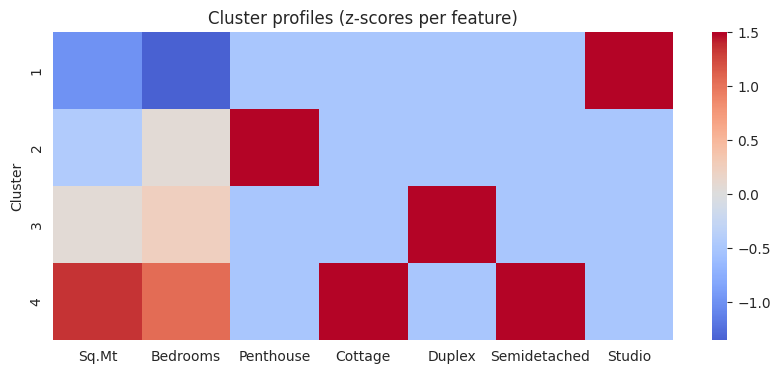

In [36]:
# Plot heatmap to visualise
cols = [c for c in df_cluster.columns if c not in ["Average", "Std.dev"]]

df_hm = (df_cluster[cols] - df_cluster[cols].mean()) / df_cluster[cols].std()

plt.figure(figsize=(10, 4))
sns.heatmap(df_hm, cmap="coolwarm", center=0, cbar=True)
plt.title("Cluster profiles (z-scores per feature)")
plt.show()

### **2.9. Reattach rent for economic profiling**

In [37]:
# Reattach rent for economic profiling
df_seg_final = df_seg.copy()
df_seg_final['Rent'] = df_clean['Rent']

print("\nRent distribution by cluster:")
display(df_seg_final.groupby('Cluster')['Rent'].describe().round(2))


Rent distribution by cluster:


,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
1,88.00,907.50,281.48,450.00,700.00,850.00,1000.00,2150.00
2,1741.00,1848.45,1283.65,450.00,990.00,1400.00,2400.00,16000.00
3,62.00,2297.39,1423.14,700.00,1212.50,2100.00,3111.75,8500.00
4,2.00,2500.00,989.95,1800.00,2150.00,2500.00,2850.00,3200.00


### **2.10. Determining cluster labels**

In [38]:
clust_labels = { # to fill in with more specific cluster labels
    1: 'Studio Apartments',
    2: 'Mid-Size Family Apartments',
    3: 'Large Duplex Units',
    4: 'Luxury Detached & Cottage Houses'
}

---
## **3. Linear Regression: OLS on the Main Apartment Segment**

We select the dominant standard-apartment cluster for supervised modelling - Cluster 2.

### **3.1 Exploratory Data Analysis and Data Preparation - Cluster 2**

In [39]:
# Extract Cluster 2 for Linear Regression
main_cluster = 2
df_reg = df_seg_final[df_seg_final['Cluster'] == main_cluster].copy()

In [40]:
# Drop segmentation label
df_reg.drop(columns=["Cluster"], inplace=True, errors="ignore")

# Drop area label
df_reg.drop(columns=["Area"], inplace=True, errors="ignore")

print(f"Selected Cluster {main_cluster} — {df_reg.shape[0]} observations")
display(df_reg.head())

Selected Cluster 2 — 1741 observations


,District,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,Studio,Rent
0,Ciudad Lineal,2.00,72,3.00,1.00,1.00,0,0,0,0,0,1300
1,Ciudad Lineal,5.00,260,2.00,1.00,1.00,0,0,0,0,0,3000
2,Ciudad Lineal,2.00,100,3.00,1.00,1.00,0,0,0,0,0,1300
3,Ciudad Lineal,3.00,120,4.00,1.00,1.00,0,0,0,0,0,1600
4,Ciudad Lineal,2.00,60,3.00,1.00,0.00,0,0,0,0,0,800


In [41]:
# Check datatypes
df_reg.dtypes

District            str
Bedrooms        float64
Sq.Mt             int64
Floor           float64
Outer           float64
Elevator        float64
Penthouse         int64
Cottage           int64
Duplex            int64
Semidetached      int64
Studio            int64
Rent              int64
dtype: object

In [42]:
df_reg.describe()

,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,Studio,Rent
count,1741.00,1741.00,1741.00,1741.00,1741.00,1741.00,1741.00,1741.00,1741.00,1741.00,1741.00
mean,2.36,115.10,3.63,0.88,0.89,0.09,0.00,0.00,0.00,0.00,1848.45
std,1.15,73.13,3.03,0.32,0.31,0.29,0.02,0.00,0.00,0.00,1283.65
min,0.00,20.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,450.00
25%,2.00,69.00,2.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,990.00
50%,2.00,90.00,3.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1400.00
75%,3.00,138.00,5.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,2400.00
max,8.00,500.00,29.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,16000.00


In [43]:
# Identify variable types within the regression subset
target = 'Rent'
numeric_all = df_reg.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_reg.select_dtypes(include=["object", "category", "string"]).columns.tolist()
binary_cols = [c for c in numeric_all if set(df_reg[c].dropna().unique()).issubset({0, 1}) and c != target]
numeric_cols = [c for c in numeric_all if c not in binary_cols and c != target]

print(f"Numeric (continuous):{numeric_cols}")
print(f"Binary:              {binary_cols}")
print(f"Categorical:         {categorical_cols}")

Numeric (continuous):['Bedrooms', 'Sq.Mt', 'Floor']
Binary:              ['Outer', 'Elevator', 'Penthouse', 'Cottage', 'Duplex', 'Semidetached', 'Studio']
Categorical:         ['District']


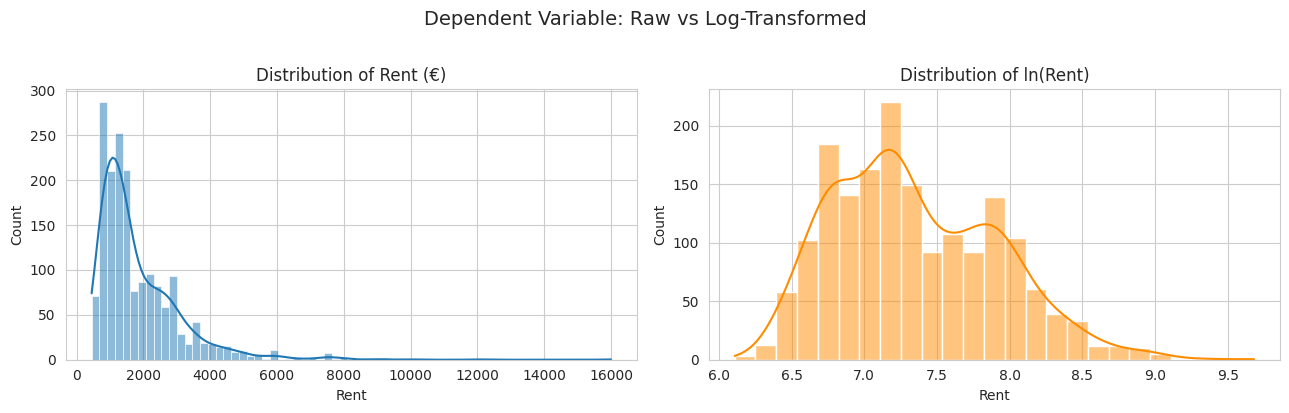

In [44]:
# Histogram of dependent variable
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_reg[target], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Rent (€)')
sns.histplot(np.log(df_reg[target]), kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of ln(Rent)')
plt.suptitle('Dependent Variable: Raw vs Log-Transformed', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

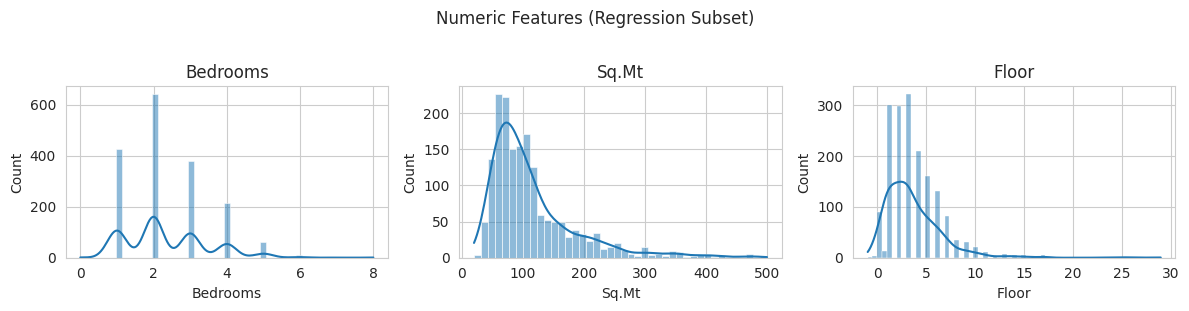

In [45]:
# EDA: numeric features within cluster
if len(numeric_cols) > 0:
    n_c = min(4, len(numeric_cols))
    n_r = (len(numeric_cols) + n_c - 1) // n_c
    fig, axes = plt.subplots(n_r, n_c, figsize=(4*n_c, 3*n_r))
    axes = np.array(axes).flatten()
    for i, col in enumerate(numeric_cols):
        sns.histplot(df_reg[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(col)
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.suptitle('Numeric Features (Regression Subset)', y=1.02)
    plt.tight_layout()
    plt.show()

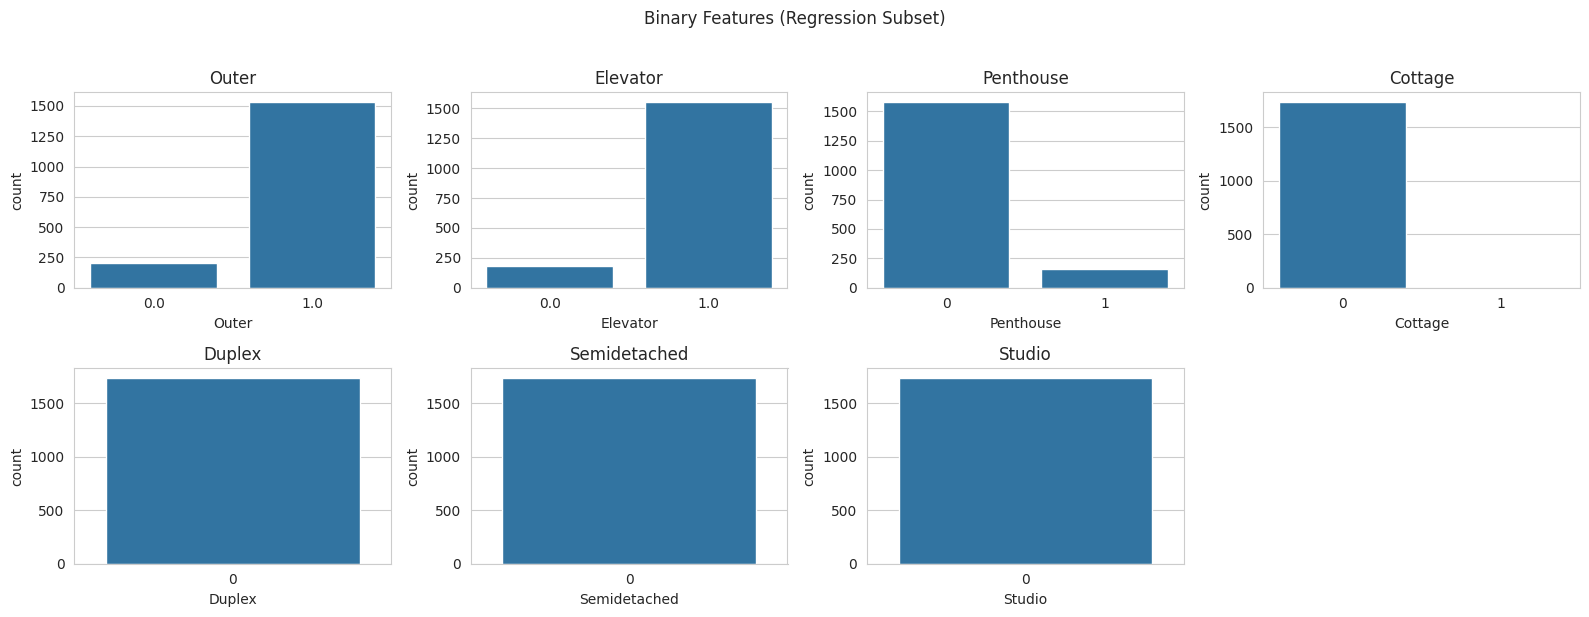

In [46]:
# EDA: binary features within cluster
if len(binary_cols) > 0:
    n_c = min(4, len(binary_cols))
    n_r = (len(binary_cols) + n_c - 1) // n_c
    fig, axes = plt.subplots(n_r, n_c, figsize=(4*n_c, 3*n_r))
    axes = np.array(axes).flatten()
    for i, col in enumerate(binary_cols):
        sns.countplot(x=df_reg[col], ax=axes[i])
        axes[i].set_title(col)
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.suptitle('Binary Features (Regression Subset)', y=1.02)
    plt.tight_layout()
    plt.show()

/var/folders/8g/cswm6ljd0h7fl4zd_8ndpblr0000gn/T/ipykernel_25188/100329605.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pct.values, y=pct.index, palette="Blues_r", ax=ax)


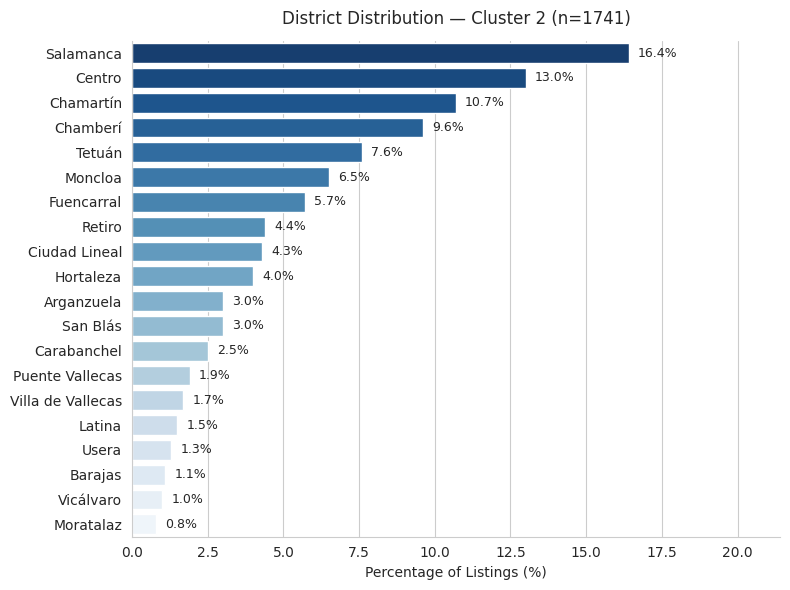

In [47]:
# EDA: categorical (District) distribution
for col in categorical_cols:
    vc = df_reg[col].value_counts()
    pct = (vc / vc.sum() * 100).round(1)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x=pct.values, y=pct.index, palette="Blues_r", ax=ax)
    
    # Add percentage labels at end of each bar
    for i, (val, name) in enumerate(zip(pct.values, pct.index)):
        ax.text(val + 0.3, i, f"{val}%", va="center", fontsize=9)
    
    ax.set_title(f"{col} Distribution — Cluster 2 (n={len(df_reg)})", fontsize=12, pad=12)
    ax.set_xlabel("Percentage of Listings (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, pct.values.max() + 5)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [48]:
# One-hot encode District (drop_first to avoid dummy variable trap)
df_reg_ohe = pd.get_dummies(df_reg, columns=categorical_cols, drop_first=True).copy()
print(f"Shape after encoding: {df_reg_ohe.shape}")

Shape after encoding: (1741, 30)


In [49]:
# Check datatypes
df_reg_ohe.dtypes

Bedrooms                      float64
Sq.Mt                           int64
Floor                         float64
Outer                         float64
Elevator                      float64
Penthouse                       int64
Cottage                         int64
Duplex                          int64
Semidetached                    int64
Studio                          int64
Rent                            int64
District_Barajas                 bool
District_Carabanchel             bool
District_Centro                  bool
District_Chamartín               bool
District_Chamberí                bool
District_Ciudad Lineal           bool
District_Fuencarral              bool
District_Hortaleza               bool
District_Latina                  bool
District_Moncloa                 bool
District_Moratalaz               bool
District_Puente Vallecas         bool
District_Retiro                  bool
District_Salamanca               bool
District_San Blás                bool
District_Tet

### **3.2 Validation**

In [50]:
# Three-way split: Model (train + test) + Reserved holdout
df_model, df_reserved = train_test_split(df_reg_ohe, test_size=0.1, random_state=42)
print(f"Model set: {df_model.shape}  |  Reserved holdout: {df_reserved.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    df_model.drop(columns=[target]),
    df_model[target],
    test_size=0.3,
    random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Model set: (1566, 30)  |  Reserved holdout: (175, 30)
Train: (1096, 29)  |  Test: (470, 29)


In [51]:
# Remove constant columns (can appear after split if rare categories land in one set)
constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant columns: {constant_cols}")
    X_train = X_train.drop(columns=constant_cols)
    X_test  = X_test.drop(columns=constant_cols)
    df_reserved = df_reserved.drop(columns=constant_cols, errors='ignore')

Dropping constant columns: ['Duplex', 'Semidetached', 'Studio']


In [52]:
# Check columns in X_train
X_train.columns

Index(['Bedrooms', 'Sq.Mt', 'Floor', 'Outer', 'Elevator', 'Penthouse',
       'Cottage', 'District_Barajas', 'District_Carabanchel',
       'District_Centro', 'District_Chamartín', 'District_Chamberí',
       'District_Ciudad Lineal', 'District_Fuencarral', 'District_Hortaleza',
       'District_Latina', 'District_Moncloa', 'District_Moratalaz',
       'District_Puente Vallecas', 'District_Retiro', 'District_Salamanca',
       'District_San Blás', 'District_Tetuán', 'District_Usera',
       'District_Vicálvaro', 'District_Villa de Vallecas'],
      dtype='str')

### **3.3 Multicollinearity Check (VIF)**

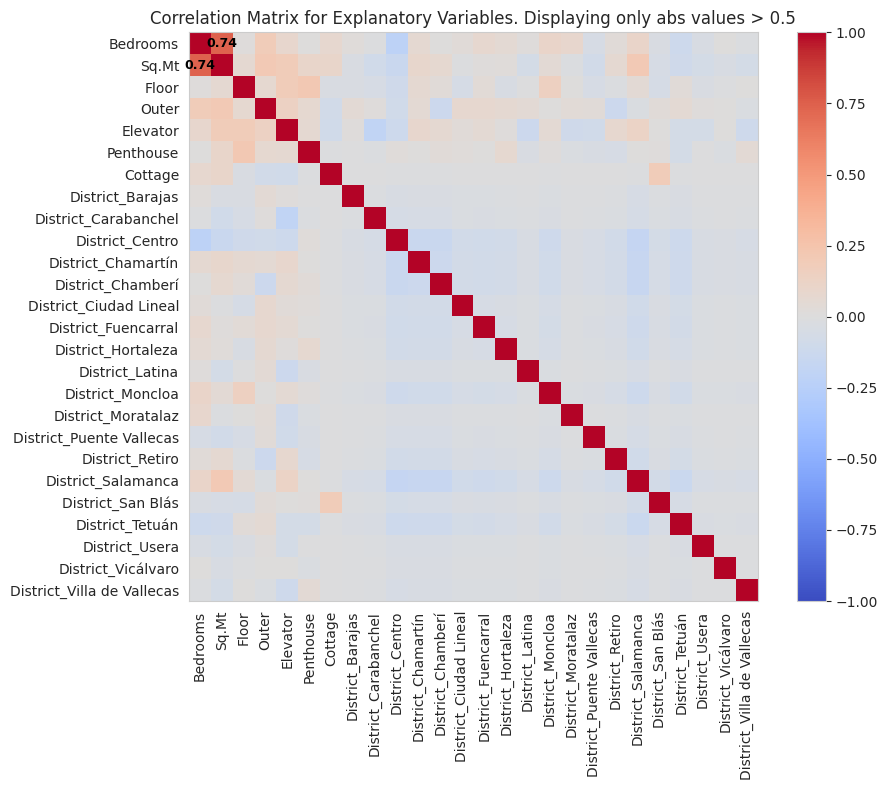

In [53]:
# Correlation heatmap for regression features (highlight |corr| ≥ 0.5)
num_pred = X_train.columns.tolist()
corr = X_train[num_pred].corr()

fig, ax = plt.subplots(figsize=(10,8))
cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        valor = corr.iloc[i, j]
        if abs(valor) >= 0.5 and i != j:
            ax.text(j, i, f'{valor:.2f}', 
                    ha='center', va='center', 
                    color='white' if abs(valor) > 0.8 else 'black',
                    fontsize=9, fontweight='bold')
            
ax.grid(False)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
plt.colorbar(cax)
ax.set_title('Correlation Matrix for Explanatory Variables. Displaying only abs values > 0.5')
plt.tight_layout()
plt.show()

In [54]:
# Calculate VIF to check for multicollinearity
X_vif = X_train.astype(float)
vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("Variance Inflation Factors:")
display(vif_data)

Variance Inflation Factors:


,Variable,VIF
0,Bedrooms,12.88
4,Elevator,10.33
1,Sq.Mt,9.52
3,Outer,9.37
20,District_Salamanca,3.26
2,Floor,2.78
10,District_Chamartín,2.60
11,District_Chamberí,2.35
9,District_Centro,2.26
16,District_Moncloa,2.05


In [55]:
# Iterative VIF removal (threshold = 10)
def remove_high_vif(df, thresh=10.0):
    df_work = df.copy()
    while True:
        vifs = pd.Series(
            [variance_inflation_factor(df_work.values, i) for i in range(df_work.shape[1])],
            index=df_work.columns
        )
        max_vif = vifs.max()
        if max_vif > thresh:
            drop_col = vifs.idxmax()
            print(f"Removing '{drop_col}' — VIF: {max_vif:.2f}")
            df_work = df_work.drop(columns=[drop_col])
        else:
            break
    return df_work

X_aftervif = remove_high_vif(X_vif, thresh=10)
print(f"\nRetained {X_aftervif.shape[1]} variables: {list(X_aftervif.columns)}")

Removing 'Bedrooms' — VIF: 12.88
Removing 'Elevator' — VIF: 10.32

Retained 24 variables: ['Sq.Mt', 'Floor', 'Outer', 'Penthouse', 'Cottage', 'District_Barajas', 'District_Carabanchel', 'District_Centro', 'District_Chamartín', 'District_Chamberí', 'District_Ciudad Lineal', 'District_Fuencarral', 'District_Hortaleza', 'District_Latina', 'District_Moncloa', 'District_Moratalaz', 'District_Puente Vallecas', 'District_Retiro', 'District_Salamanca', 'District_San Blás', 'District_Tetuán', 'District_Usera', 'District_Vicálvaro', 'District_Villa de Vallecas']


### **3.4 Feature Selection and Model Fitting**

In [56]:
# Recursive Feature Elimination with Cross-Validation
base_model = LinearRegression()
rfecv = RFECV(
    estimator=base_model,
    step=1,
    cv=RepeatedKFold(n_splits=5, n_repeats=3),
    scoring='neg_mean_squared_error'
)

In [57]:
pipeline_rfe = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', rfecv),
    ('regressor', base_model)
])

pipeline_rfe.fit(X_aftervif, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearRegression()
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection

In [58]:
# Get the real names of the selected features
feature_names = X_aftervif.columns
selected_features = feature_names[rfecv.support_].tolist()

In [59]:
# Extract results from pipeline, accessing the internal 'regressor' which was trained ONLY on selected features
optimized_model = pipeline_rfe.named_steps['regressor']
betas = optimized_model.coef_
intercept = optimized_model.intercept_

In [60]:
# Run RFECV
rfecv_detector = pipeline_rfe.named_steps['feature_selection']

ranking_df = pd.DataFrame({
    'Feature': X_aftervif.columns,
    'Ranking': rfecv_detector.ranking_,
    'Selected': rfecv_detector.support_
})

ranking_df = ranking_df.sort_values(by='Ranking')

display(ranking_df)

,Feature,Ranking,Selected
0,Sq.Mt,1,True
21,District_Usera,1,True
20,District_Tetuán,1,True
19,District_San Blás,1,True
18,District_Salamanca,1,True
17,District_Retiro,1,True
16,District_Puente Vallecas,1,True
15,District_Moratalaz,1,True
14,District_Moncloa,1,True
13,District_Latina,1,True


In [61]:
# Scale data manually to match the Pipeline's internal state
import statsmodels.api as sm                 

scaler = pipeline_rfe.named_steps['scaler']
X_scaled = scaler.transform(X_aftervif) # Scale all variables
X_selected_scaled = X_scaled[:, rfecv.support_] # Keep only selected by RFE

# Statsmodels prefers to work with dataframes
X_stat = pd.DataFrame(
    X_selected_scaled, 
    columns=selected_features, 
    index=X_vif.index  
)

X_stat_with_const = sm.add_constant(X_stat)
ols_stats = sm.OLS(y_train, X_stat_with_const).fit()

results_summary = pd.DataFrame({
    'Variable': selected_features,
    'Standardised Beta (scaled)': betas,
    'p-value': ols_stats.pvalues[1:] # Exclude constant
}).sort_values(by='p-value')

print(f"Model Intercept: {intercept:.2f}")
print(f"R-squared: {ols_stats.rsquared:.3f}")

format_pvi = {
    'Standardised Beta (scaled)': '{:.2f}'.format,
    'p-value': '{:.3f}'.format
}

print("-" * 45)
print(results_summary.to_string(index=False, formatters=format_pvi))
print("-" * 45)

Model Intercept: 1852.41
R-squared: 0.713
---------------------------------------------
                  Variable Standardised Beta (scaled) p-value
                     Sq.Mt                     973.58   0.000
        District_Salamanca                     260.24   0.000
           District_Centro                     205.43   0.000
                     Floor                      77.29   0.001
           District_Retiro                      95.57   0.005
                   Cottage                     -60.09   0.007
         District_Chamberí                     115.00   0.011
        District_Chamartín                      84.21   0.064
                     Outer                      38.93   0.091
       District_Fuencarral                     -60.24   0.095
          District_Moncloa                      58.68   0.127
        District_Moratalaz                     -37.00   0.132
        District_Vicálvaro                     -35.69   0.147
                 Penthouse                  

In [62]:
# Backward elimination on RFECV-selected features
def backward_elimination(X, y, threshold=0.05):
    features = list(X.columns)
    while len(features) > 0:
        X_const = sm.add_constant(X[features])
        model = sm.OLS(y, X_const).fit()
        pvals = model.pvalues.drop('const')
        max_p = pvals.max()
        if max_p > threshold:
            drop = pvals.idxmax()
            features.remove(drop)
            print(f"Removing '{drop}' — p-value: {max_p:.4f}")
        else:
            break
    return model, features

X_final = X_aftervif[selected_features]
final_model, final_features = backward_elimination(X_final, y_train)

print("\n" + "="*78)
print("OLS MODEL (Level)")
print("="*78)
print(final_model.summary())

Removing 'District_Hortaleza' — p-value: 0.5965
Removing 'District_Usera' — p-value: 0.5394
Removing 'District_Ciudad Lineal' — p-value: 0.6103
Removing 'District_Barajas' — p-value: 0.5014
Removing 'District_Puente Vallecas' — p-value: 0.5094
Removing 'District_Latina' — p-value: 0.5082
Removing 'District_San Blás' — p-value: 0.5431
Removing 'District_Villa de Vallecas' — p-value: 0.5456
Removing 'District_Carabanchel' — p-value: 0.5565
Removing 'District_Vicálvaro' — p-value: 0.3425
Removing 'District_Moratalaz' — p-value: 0.3293
Removing 'District_Fuencarral' — p-value: 0.3697
Removing 'Penthouse' — p-value: 0.1347
Removing 'Outer' — p-value: 0.0835

OLS MODEL (Level)
                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     265.6
Date

In [63]:
# Standardised betas for final model features only
final_betas = pd.DataFrame({
    'Feature': final_features,
    'Standardised Beta': final_model.params[final_features] * X_final[final_features].std()
})
final_betas = final_betas.reindex(final_betas['Standardised Beta'].abs().sort_values(ascending=False).index)
final_betas = final_betas.reset_index(drop=True)
print(final_betas.to_string(index=False))

           Feature  Standardised Beta
             Sq.Mt             989.94
District_Salamanca             320.66
   District_Centro             264.69
 District_Chamberí             164.85
District_Chamartín             139.43
   District_Retiro             124.58
  District_Moncloa             101.28
   District_Tetuán              93.39
             Floor              83.65
           Cottage             -66.26


### **3.5 Prediction and Evaluation: Level-Level Model on Train Dataset**

#### ***3.5.1 Create Predictions***

In [64]:
def pred_chart(y_pred, y, dataset="train"):
    y = pd.to_numeric(pd.Series(y), errors="coerce").astype(float)
    y_pred = pd.to_numeric(pd.Series(y_pred), errors="coerce").astype(float)

    mask = y.notna() & y_pred.notna()
    y = y[mask].values
    y_pred = y_pred[mask].values
    
    plt.figure(figsize=(10, 4))
    plt.title(f"Real vs. Fitted ({dataset} dataset)", fontsize=14)
    plt.scatter(y, y_pred, alpha=0.5) 
    
    coef = np.polyfit(y, y_pred, 1)  
    poly1d_fn = np.poly1d(coef)  
    plt.plot(y, poly1d_fn(y), color="red", label="Regression line")
    
    plt.xlabel("Real")
    plt.ylabel("Fitted")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6) 
    plt.show()

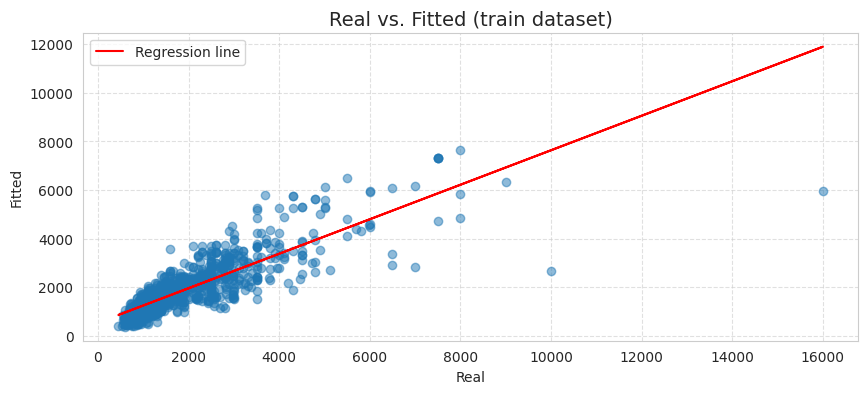

In [65]:
# Create predictions on train dataset
expected_cols = final_model.model.exog_names
X_train_final_const = sm.add_constant(X_final, has_constant="add")

X_train_final_const = X_train_final_const.reindex(columns=expected_cols, fill_value=0)
y_train_pred = final_model.predict(X_train_final_const)

pred_chart(y_train_pred, y_train)

#### ***3.5.2 Evaluate Residuals***

In [66]:
def Hist_resid(y, y_pred, dataset="train"):
    errors = y - y_pred
    plt.figure(figsize=(10, 4))
    sns.histplot(errors, kde=True, color="skyblue", edgecolor="white")
    plt.title(f"Histogram of residuals ({dataset} dataset)", fontsize=15, pad=15)
    plt.xlabel("Error")
    plt.ylabel("Frequence")
    plt.axvline(x=0, color='red', linestyle='--', label='Error zero')
    plt.legend()
    plt.show()

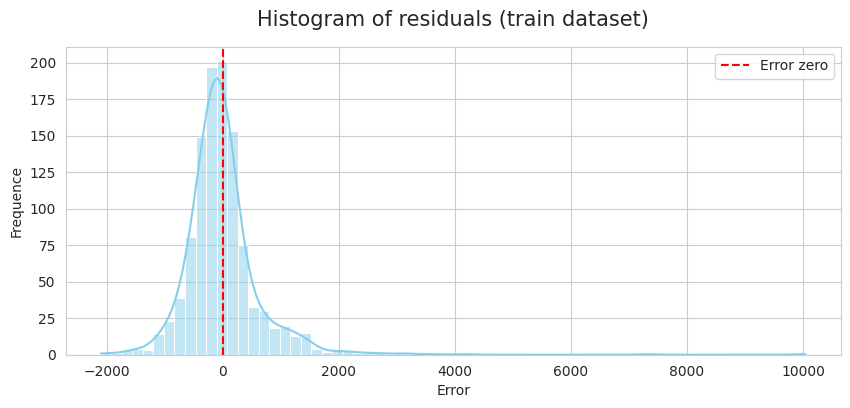

In [67]:
Hist_resid(y_train, y_train_pred, "train")

In [68]:
# Check for normality with a QQ plot
def qq_plot_resid(residuals, dataset="train"):
    plt.figure(figsize=(6,6))
    sm.qqplot(residuals, line='s')
    plt.title(f"QQ Plot of Residuals ({dataset}) dataset")
    plt.show()

<Figure size 600x600 with 0 Axes>

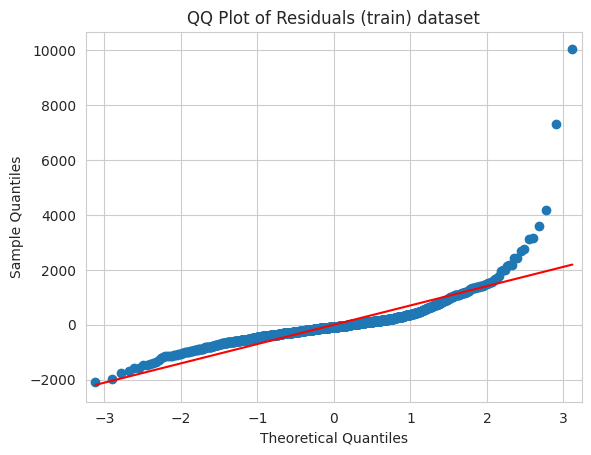

In [69]:
residuals_train = y_train - y_train_pred
qq_plot_resid(residuals_train, "train")

In [70]:
# Check for heteroskedasticity
def resid_vs_fitted(y, y_pred, dataset="train"):
    residuals = y - y_pred
    
    plt.figure(figsize=(6,2))
    plt.scatter(y_pred, residuals, alpha=0.4)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs Fitted ({dataset})")
    plt.show()

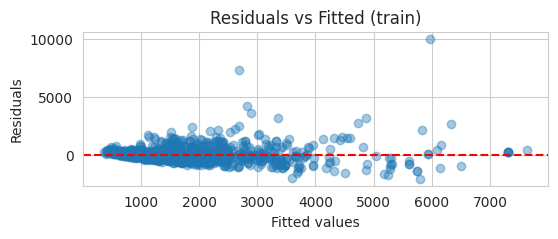

In [71]:
resid_vs_fitted(y_train, y_train_pred, "train")

#### ***3.5.3 Regression Evaluation Metrics***

In [72]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def eval_metrics(y, y_pred, dataset="train"):
    y = pd.to_numeric(pd.Series(y), errors="coerce").values
    y_pred = pd.to_numeric(pd.Series(y_pred), errors="coerce").values

    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mape_pct = np.mean(np.abs((y - y_pred) / y)) * 100
    r2 = r2_score(y, y_pred)

    results = pd.DataFrame({
        dataset: [mae, mse, rmse, mape_pct, f"{r2:.4f}"]
    }, index=["MAE", "MSE", "RMSE", "MAPE %", "R-squared"])

    return results

In [73]:
print("Level-Level Model (train)")

eval_metrics(y_train, y_train_pred)

Level-Level Model (train)


,train
MAE,417.74
MSE,493569.49
RMSE,702.55
MAPE %,22.95
R-squared,0.7100


## **3.6. Prediction and Evaluation: Log-Level Model on Train Dataset**

We explore applying a log transformation on Rent and analyse whether it is appropriate.

In [74]:
# Check for presence of any zeros or negative values in target variable
print((y_train<0).sum())

0


In [75]:
# Apply log transformation on target variable
y_train_log = np.log(y_train)

### ***3.6.1. Fitting the Model + Predictions on Model (train) data***

In [76]:
# Run backward elimination separately for the log model
log_model, log_features = backward_elimination(X_final, y_train_log)
X_train_const = sm.add_constant(X_final[log_features], has_constant="add")

Removing 'District_Tetuán' — p-value: 0.4080
Removing 'District_Hortaleza' — p-value: 0.5342
Removing 'District_Ciudad Lineal' — p-value: 0.4659
Removing 'Cottage' — p-value: 0.4024
Removing 'District_Fuencarral' — p-value: 0.1738
Removing 'District_Barajas' — p-value: 0.1011
Removing 'Penthouse' — p-value: 0.0801


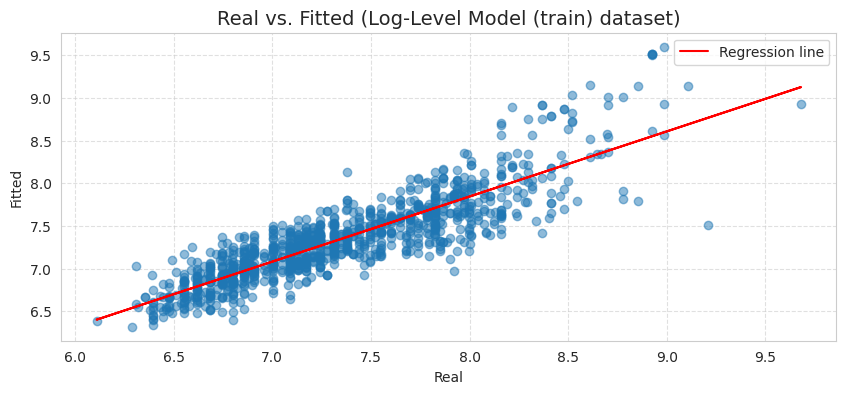

In [77]:
# Create predictions
y_train_pred_log = log_model.predict(
    sm.add_constant(X_final[log_features], has_constant="add")
)
pred_chart(y_train_pred_log, y_train_log, "Log-Level Model (train)")

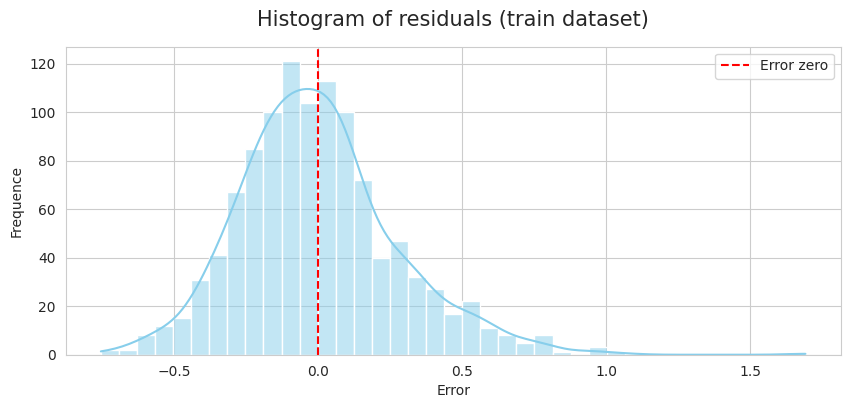

In [78]:
# Examine residuals
Hist_resid(y_train_log, y_train_pred_log, "train")

<Figure size 600x600 with 0 Axes>

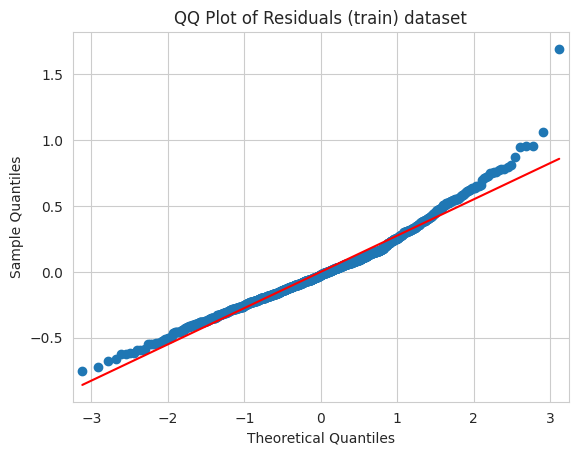

In [79]:
residuals_train_log = y_train_log - y_train_pred_log
qq_plot_resid(residuals_train_log, "train")

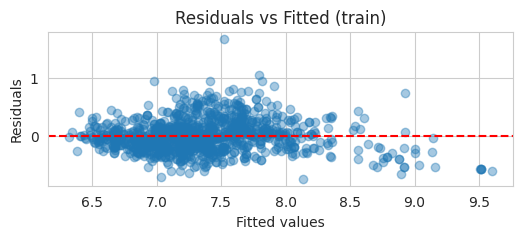

In [80]:
resid_vs_fitted(y_train_log, y_train_pred_log, "train")

### ***3.6.2. Compare Level-Level Model and Log-Level Model***

In [81]:
# Back-transform log predictions to € before comparing (like-for-like)
y_train_pred_log_eur = pd.Series(
    np.exp(y_train_pred_log.values),
    index=y_train.index
)

level_train = eval_metrics(y_train, y_train_pred,         "Level-Level, train")
log_train   = eval_metrics(y_train, y_train_pred_log_eur, "Log-Level, train")

compare_levellog = pd.concat([level_train, log_train], axis=1)
compare_levellog

,"Level-Level, train","Log-Level, train"
MAE,417.74,448.49
MSE,493569.49,752893.27
RMSE,702.55,867.69
MAPE %,22.95,20.96
R-squared,0.7100,0.5576


Since evaluation metrics for Level-Level model is better than Log-Level model, the final model we will be going ahead with is Level-Level model. With that, we can proceed to test and evaluate the reserved dataset.

### **3.7 Prediction and Evaluation: Level-Level Model on Test Dataset**

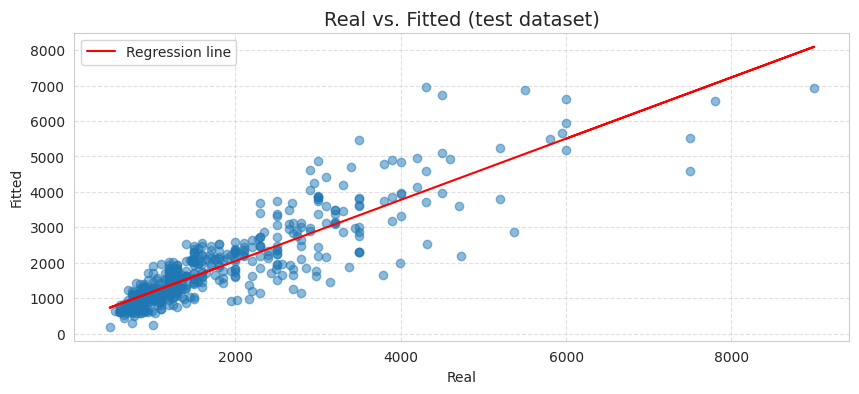

In [82]:
# Prepare test set with same columns as final model
X_test_final = sm.add_constant(X_test[final_features], has_constant="add")
expected_cols = final_model.model.exog_names
X_test_final = X_test_final.reindex(columns=expected_cols, fill_value=0)

y_test_pred = final_model.predict(X_test_final)
pred_chart(y_test_pred, y_test, "test")

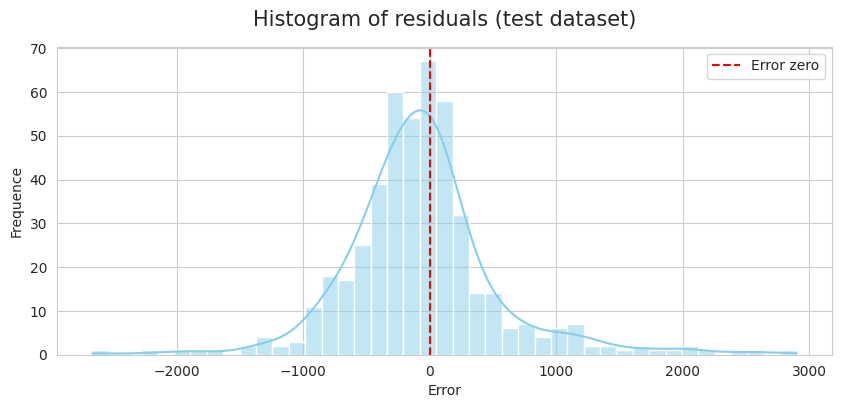

<Figure size 600x600 with 0 Axes>

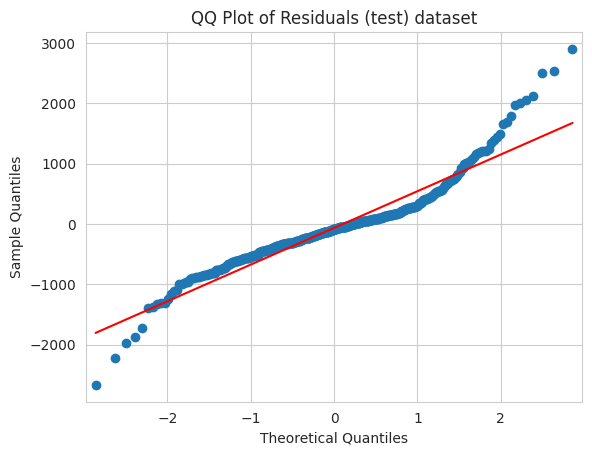

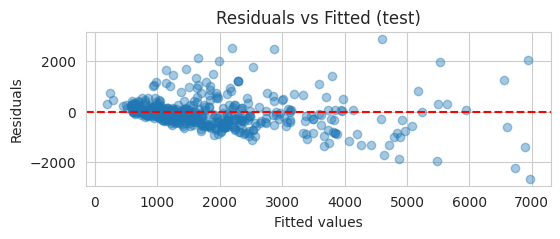

In [83]:
# Residual diagnostics on test data
Hist_resid(y_test, y_test_pred, "test")
residuals_test = y_test - y_test_pred
qq_plot_resid(residuals_test, "test")
resid_vs_fitted(y_test, y_test_pred, "test")

In [84]:
# Compare train vs test evaluation metrics
test_metrics = eval_metrics(y_test, y_test_pred, "Level-Level, test")
compare_traintest = pd.concat([level_train, test_metrics], axis=1)
compare_traintest

,"Level-Level, train","Level-Level, test"
MAE,417.74,418.34
MSE,493569.49,374554.80
RMSE,702.55,612.01
MAPE %,22.95,23.13
R-squared,0.7100,0.7490


### **3.8. Level-Level Model Evaluation on Reserved data**

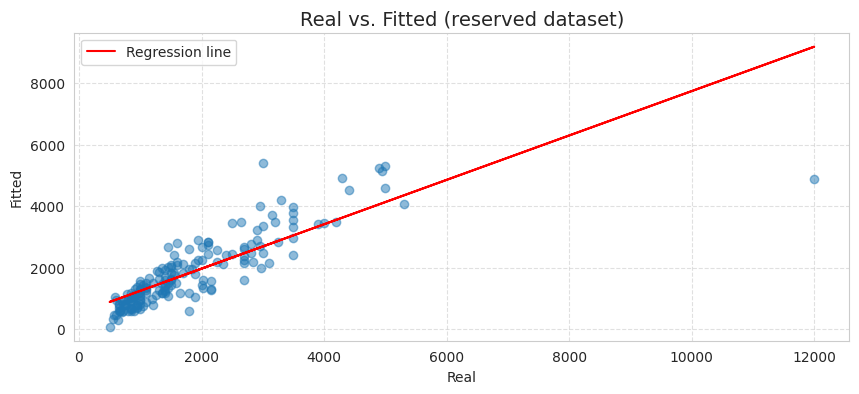

In [85]:
# Prepare reserved set with same columns as final model
X_reserved = df_reserved[final_features]
X_reserved_const = sm.add_constant(X_reserved, has_constant="add")
X_reserved_const = X_reserved_const.reindex(columns=expected_cols, fill_value=0)
y_reserved = df_reserved[target]

y_reserved_pred = final_model.predict(X_reserved_const)
pred_chart(y_reserved_pred, y_reserved, "reserved")

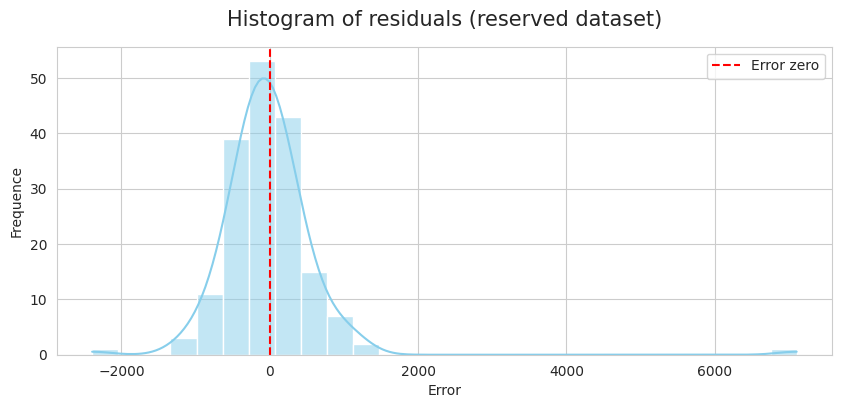

<Figure size 600x600 with 0 Axes>

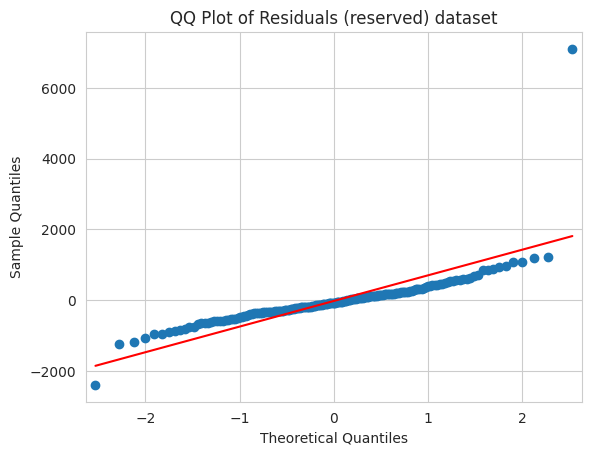

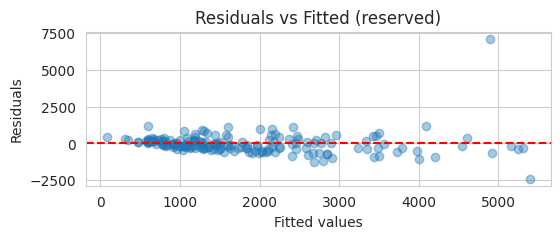

In [86]:
# Residual diagnostics on reserved set
Hist_resid(y_reserved, y_reserved_pred, "reserved")

residuals_reserved = y_reserved - y_reserved_pred
qq_plot_resid(residuals_reserved, "reserved")
resid_vs_fitted(y_reserved, y_reserved_pred, "reserved")

In [87]:
reserved_metrics = eval_metrics(y_reserved, y_reserved_pred, "Level-Level, reserved")
compare_all = pd.concat([level_train, test_metrics, reserved_metrics], axis=1)

# Ensure numeric
compare_all = compare_all.apply(pd.to_numeric, errors="coerce")

# Difference columns
compare_all["Test vs Train"] = compare_all["Level-Level, test"] - compare_all["Level-Level, train"]
compare_all["Reserved vs Train"] = compare_all["Level-Level, reserved"] - compare_all["Level-Level, train"]

def color_diff(val):
    if pd.isna(val):
        return ""
    if abs(val) <= 0.02:
        return "background-color: #c6efce; color: #276221"  # green
    elif abs(val) <= 0.05:
        return "background-color: #ffeb9c; color: #9c6500"  # yellow
    else:
        return "background-color: #ffc7ce; color: #9c0006"  # red

styled = (
    compare_all.style
    .format("{:.2f}", na_rep="")  # default 2dp
    .format("{:.4f}", na_rep="", subset=pd.IndexSlice[["R-squared"], :])
    .map(
        color_diff,
        subset=pd.IndexSlice[["R-squared"], ["Test vs Train", "Reserved vs Train"]]
    )
)

styled

,"Level-Level, train","Level-Level, test","Level-Level, reserved",Test vs Train,Reserved vs Train
MAE,417.74,418.34,404.18,0.61,-13.56
MSE,493569.49,374554.80,525844.51,-119014.70,32275.01
RMSE,702.55,612.01,725.15,-90.54,22.61
MAPE %,22.95,23.13,23.22,0.18,0.27
R-squared,0.7100,0.7490,0.6935,0.0390,-0.0165


#### ***Regularisation Comparison (Extra)***

In [88]:
# Quick comparison: OLS vs Ridge vs Lasso to confirm model choice
from sklearn.model_selection import cross_val_score

X_reg_compare = X_final[final_features]

print("Model Comparison (5-fold CV on training data):")
print("-" * 50)
for name, model in [("OLS (Linear)", LinearRegression()), 
                     ("Ridge (α=1.0)", Ridge(alpha=1.0)),
                     ("Lasso (α=1.0)", Lasso(alpha=1.0))]:
    scores = cross_val_score(model, X_reg_compare, y_train, cv=5, scoring='r2')
    print(f"  {name:20s}: R² = {scores.mean():.4f} ± {scores.std():.4f}")


Model Comparison (5-fold CV on training data):
--------------------------------------------------
  OLS (Linear)        : R² = 0.7119 ± 0.0746
  Ridge (α=1.0)       : R² = 0.7121 ± 0.0749
  Lasso (α=1.0)       : R² = 0.7119 ± 0.0749


## **4. Business Application: Pricing Analysis and Recommendations**

Now that we have identified the appropriate linear regression model, we will be using this model to analyse the rent prices in the entire dataset. Note: We are not retraining the data with the entire dataset, we are simply using the model identified in the Part 3 to generate price predictions and compare with their actual prices to identify opportunities. 

In [89]:
X_pricing = df_reg_ohe.drop(columns=[target])
y_pricing = df_reg_ohe[target]

X_pricing = X_pricing.reindex(columns=final_features, fill_value=0)
X_pricing_const = sm.add_constant(X_pricing, has_constant="add")

# Use the already-validated model
df_pricing = df_reg_ohe.copy()
df_pricing["predicted_rent"] = final_model.predict(X_pricing_const)
df_pricing["pricing_gap"] = df_pricing[target] - df_pricing["predicted_rent"]
df_pricing["pricing_gap_pct"] = 100 * df_pricing["pricing_gap"] / df_pricing["predicted_rent"]

df_pricing.head()

,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,Studio,Rent,District_Barajas,District_Carabanchel,District_Centro,District_Chamartín,District_Chamberí,District_Ciudad Lineal,District_Fuencarral,District_Hortaleza,District_Latina,District_Moncloa,District_Moratalaz,District_Puente Vallecas,District_Retiro,District_Salamanca,District_San Blás,District_Tetuán,District_Usera,District_Vicálvaro,District_Villa de Vallecas,predicted_rent,pricing_gap,pricing_gap_pct
0,2.00,72,3.00,1.00,1.00,0,0,0,0,0,1300,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,830.00,470.00,56.63
1,5.00,260,2.00,1.00,1.00,0,0,0,0,0,3000,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,3403.51,-403.51,-11.86
2,2.00,100,3.00,1.00,1.00,0,0,0,0,0,1300,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,1217.40,82.60,6.78
3,3.00,120,4.00,1.00,1.00,0,0,0,0,0,1600,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,1521.77,78.23,5.14
4,2.00,60,3.00,1.00,0.00,0,0,0,0,0,800,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,663.96,136.04,20.49


In [90]:
# Reattach District for business interpretation
df_pricing['District'] = df_reg.loc[df_pricing.index, 'District']

# Pricing status labels
df_pricing['Actual vs Predicted'] = pd.cut(
    df_pricing['pricing_gap_pct'],
    bins=[-np.inf, -20, 20, np.inf],
    labels=['Underpriced', 'Fairly Priced', 'Overpriced']
)

print("Actual vs Predicted Prices")
print(df_pricing['Actual vs Predicted'].value_counts())
print(f"\nAverage pricing gap: {df_pricing['pricing_gap_pct'].mean():.2f}%")
print(f"Median pricing gap: {df_pricing['pricing_gap_pct'].median():.2f}%")
print(f"Std of pricing gap: {df_pricing['pricing_gap_pct'].std():.2f}%")

Actual vs Predicted Prices
Actual vs Predicted
Fairly Priced    935
Underpriced      437
Overpriced       369
Name: count, dtype: int64

Average pricing gap: 1.97%
Median pricing gap: -5.69%
Std of pricing gap: 35.20%


In [91]:
# Pricing gaps by districts
district_summary = df_pricing.groupby('District').agg(
    listings=('Rent', 'count'),
    avg_actual=('Rent', 'mean'),
    avg_predicted=('predicted_rent', 'mean'),
    underpriced=('Actual vs Predicted', lambda x: (x == 'Underpriced').sum()),
    overpriced=('Actual vs Predicted', lambda x: (x == 'Overpriced').sum())
).round(0)

district_summary['underpriced proportion %'] = (
    district_summary['underpriced'] / district_summary['listings'] * 100
).round(1)

district_summary['overpriced proportion %'] = (
    district_summary['overpriced'] / district_summary['listings'] * 100
).round(1)

district_summary.sort_values(
    by=['listings', 'underpriced proportion %'],
    ascending=[False, False])

styled_district = (
    district_summary
    .sort_values(
        by=['listings', 'underpriced proportion %'],
        ascending=[False, False]
    )
    .style
    .format({
        'avg_actual': '{:.2f}',
        'avg_predicted': '{:.2f}',
        'underpriced proportion %': '{:.1f}',
        'overpriced proportion %': '{:.1f}'
    })
    .background_gradient(
        cmap='Greens',
        subset=['underpriced proportion %']
    )
    .background_gradient(
        cmap='Reds',
        subset=['overpriced proportion %']
    )
)

styled_district

,listings,avg_actual,avg_predicted,underpriced,overpriced,underpriced proportion %,overpriced proportion %
District,,,,,,,
Salamanca,286,2863.00,2861.26,87,58,30.4,20.3
Centro,227,1779.00,1873.91,81,34,35.7,15.0
Chamartín,187,2093.00,2114.20,44,27,23.5,14.4
Chamberí,167,2178.00,2178.33,37,37,22.2,22.2
Tetuán,133,1449.00,1442.72,30,22,22.6,16.5
Moncloa,113,2003.00,2058.93,39,25,34.5,22.1
Fuencarral,99,1407.00,1509.32,14,19,14.1,19.2
Retiro,76,2315.00,2330.66,28,12,36.8,15.8
Ciudad Lineal,74,1444.00,1380.82,6,27,8.1,36.5


In [92]:
# Top 10 underpriced properties — best rental opportunities for the agency
show_cols = ['District', 'Sq.Mt', 'Bedrooms', 'Floor', 'Rent', 
             'predicted_rent', 'pricing_gap_pct', 'Actual vs Predicted']

In [93]:
top_underpriced = (
    df_pricing[df_pricing["Actual vs Predicted"] == "Underpriced"]
    .sort_values("pricing_gap_pct")
    .head(10)[show_cols]
).copy()

gap_num = pd.to_numeric(top_underpriced["pricing_gap_pct"], errors="coerce")

def fmt_2dp(x):
    try:
        return f"{float(x):.2f}"
    except:
        return x

display(
    top_underpriced.style
        .format(fmt_2dp)  # applies to ALL columns, but only changes numeric-like values
        .background_gradient(cmap="Greens_r", subset=["pricing_gap_pct"], gmap=gap_num)
)

,District,Sq.Mt,Bedrooms,Floor,Rent,predicted_rent,pricing_gap_pct,Actual vs Predicted
808,Salamanca,200.00,2.00,7.00,1600.00,3592.75,-55.47,Underpriced
677,Salamanca,85.00,2.00,-0.50,925.00,1794.27,-48.45,Underpriced
354,Latina,150.00,1.00,3.00,1000.00,1909.20,-47.62,Underpriced
1154,Centro,50.00,2.00,5.00,730.00,1366.38,-46.57,Underpriced
2070,Vicálvaro,98.00,3.00,7.00,700.00,1300.32,-46.17,Underpriced
703,Salamanca,136.00,4.00,6.00,1450.00,2679.60,-45.89,Underpriced
698,Salamanca,95.00,2.00,3.00,1100.00,2029.39,-45.80,Underpriced
709,Salamanca,53.00,1.00,7.00,850.00,1558.86,-45.47,Underpriced
1268,Centro,80.00,2.00,2.00,940.00,1698.52,-44.66,Underpriced
505,Moncloa,102.00,3.00,0.00,870.00,1570.75,-44.61,Underpriced


In [94]:
top_overpriced = (
    df_pricing[df_pricing["Actual vs Predicted"] == "Overpriced"]
    .sort_values("pricing_gap_pct", ascending=False)
    .head(10)[show_cols]
).copy()

gap_num = pd.to_numeric(top_overpriced["pricing_gap_pct"], errors="coerce")

def fmt_2dp(x):
    try:
        return f"{float(x):.2f}"
    except:
        return x

print("Top 10 Most Overpriced Properties:")

display(
    top_overpriced.style
        .format(fmt_2dp)
        .background_gradient(
            cmap="Reds",
            subset=["pricing_gap_pct"],
            gmap=gap_num
        )
)

Top 10 Most Overpriced Properties:


,District,Sq.Mt,Bedrooms,Floor,Rent,predicted_rent,pricing_gap_pct,Actual vs Predicted
989,Arganzuela,25.00,1.00,-0.50,500.00,82.94,502.82,Overpriced
1020,Arganzuela,30.00,1.00,3.00,999.00,248.89,301.39,Overpriced
1926,Tetuán,185.00,2.00,1.00,10000.00,2679.92,273.15,Overpriced
92,Ciudad Lineal,55.00,1.00,3.00,1800.00,594.78,202.63,Overpriced
1188,Centro,390.00,4.00,1.00,16000.00,5960.02,168.46,Overpriced
1004,Arganzuela,35.00,1.00,2.00,750.00,290.42,158.25,Overpriced
427,Moncloa,56.00,1.00,7.00,2800.00,1127.82,148.27,Overpriced
581,Puente Vallecas,30.00,1.00,1.00,480.00,193.59,147.94,Overpriced
902,Salamanca,155.00,3.00,2.00,7000.00,2831.90,147.18,Overpriced
761,Salamanca,300.00,3.00,4.00,12000.00,4893.40,145.23,Overpriced
